# Setting Tasks

# Task 1
[ 2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17,
7, 5, 20, 17, 18, 10]

Response format: 
Programming code in jupyter notebook/colab/etc. containing the following:  
1)  Generating list of 26 random values, 
2)  Function that calculates the depth of deepest lake 
3)  Result of calculation for provided sample of 26 integers 
4)  Visualization  

# works

In [822]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Generate random array of 26 values
rnd_data = [random.randint(1, 25) for _ in range(26)]
print("Generated data:", rnd_data)

# Task data
example_data = [ 2, 7, 25, 14, 14, # 0-4
                21, 20, 6, 13, 3,
                23, 14, 1, 8, 1,
                8, 16, 21, 2, 17,
                7, 5, 20, 17, 18, 10] # 26 elements, index 0 to 25

def select_subregion(arr, start_idx, end_idx):
    return arr[start_idx:end_idx]

def calculate_deaph_level(arr):
    # water level - height of terrain
    """
    Calculates the water depth at each point of the terrain.
    """
    if len(arr) < 3:
        return 0
    
    left_wall = np.maximum.accumulate(arr)
    right_wall = np.maximum.accumulate(arr[::-1])[::-1] 
    water_level = np.minimum(left_wall, right_wall) - arr

    return water_level

def get_nearest_walls(arr):
    # input - array of heights
    # output - array of indexes of the nearest walls for each point
    deap_level = calculate_deaph_level(arr)
    water_level = deap_level + arr
    left_borders = np.arange(len(arr), dtype=int)
    right_borders = np.arange(len(arr), dtype=int)
    
    for i in range(len(arr)):
        if deap_level[i] > 0:
            l = i
            while l > 0 and arr[l] < water_level[i]:
                l -= 1
            left_borders[i] = l
            r = i
            while r < len(arr) - 1 and arr[r] < water_level[i]:
                r += 1
            right_borders[i] = r
        else:
            left_borders[i] = i
            right_borders[i] = i


    return left_borders, right_borders

def find_idx_walls_for_deepest_lake(arr):
    # input - array of heights
    # output - indexes of the walls for the deepest lake for each point , example 3 deapest lake
    pair_idx_wall = np.arange(2)
    arr_idx_wall_for_deepest = []

    arr_depths_example = calculate_deaph_level(arr)
    deaph = max(arr_depths_example)
    count_deaph = list(arr_depths_example).count(deaph)
    indexes_deaph = [i for i, x in enumerate(arr_depths_example) if x == deaph]
    left_indexes_wall, right_indexes_wall = get_nearest_walls(arr)

    for idx in range(len(indexes_deaph)):
        pair_idx_wall[0] = left_indexes_wall[indexes_deaph[idx]]
        pair_idx_wall[1] = right_indexes_wall[indexes_deaph[idx]]   

        arr_idx_wall_for_deepest.append( pair_idx_wall.copy())
        
    return indexes_deaph, arr_idx_wall_for_deepest
    
def visualize_with_highlights(arr, start_idx=None, end_idx=None, highest_idxs=None):
    x = list(range(len(arr)))
    terrain = arr

    plt.figure(figsize=(12, 5))
    plt.plot(x, arr, marker="o", label="Heights")
    
    if start_idx is not None and end_idx is not None:
        sub_x = list(range(start_idx, end_idx))
        sub_y = arr[start_idx:end_idx]
        # plt.fill_between(sub_x, sub_y, alpha=0.3, label="Subregion")
        plt.fill_between(sub_x, terrain[start_idx:end_idx], terrain[highest_idxs[1]], color='skyblue', alpha=0.4, label="Subregion")
    
    if highest_idxs:
        for idx in highest_idxs:
            plt.scatter(idx, arr[idx], s=100, color="red", zorder=5, label="Wall Highest" if idx == highest_idxs[0] else "")
    
    plt.title("Trapping Rain Water")
    plt.xlabel("Index")
    plt.ylabel("Height")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Generated data: [11, 11, 12, 22, 1, 24, 24, 22, 17, 10, 16, 25, 14, 2, 21, 23, 9, 15, 20, 1, 9, 6, 19, 6, 9, 13]


# answer data const

Const data: [2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17, 7, 5, 20, 17, 18, 10]
depth of the deepest lake
20
index of deapest lake
[9, 12, 14]
arr lakes
[array([ 2, 10]), array([10, 17]), array([10, 17])]


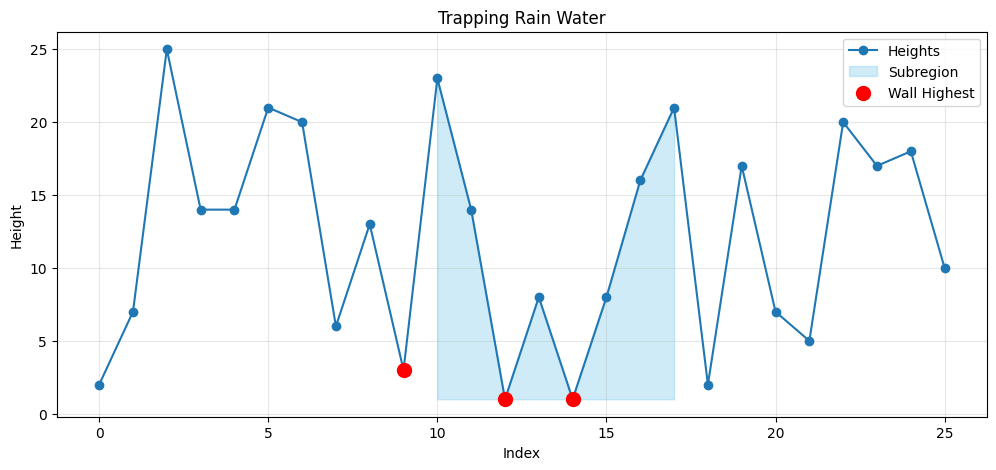

In [823]:
print("Const data:", example_data)
arr_depths_example = calculate_deaph_level(example_data)
deaph = max(arr_depths_example)
left_indexes_wall, right_indexes_wall = get_nearest_walls(example_data)
# print("Indexes of the deepest lake:", left_indexes_wall, right_indexes_wall)

# 3 deapest lakes
# if number of deaphs lakes is more than 1, then we print all indexes
indexes_deaph, arr_idx_wall = find_idx_walls_for_deepest_lake(example_data)

print("depth of the deepest lake", deaph,"index of deapest lake", indexes_deaph,"arr lakes", arr_idx_wall, sep="\n")

idx1, idx2, idx3 = indexes_deaph[0], indexes_deaph[1], indexes_deaph[2]

visualize_with_highlights(example_data, arr_idx_wall[1][0], arr_idx_wall[1][1] + 1, highest_idxs=[idx1, idx2, idx3])
# visualize_deaphs(example_data)


# answer random data

Generated data: [11, 11, 12, 22, 1, 24, 24, 22, 17, 10, 16, 25, 14, 2, 21, 23, 9, 15, 20, 1, 9, 6, 19, 6, 9, 13]
depth of the deepest lake
21
count of the deepest lake
2
index of deapest lake
[4, 13]
arr lakes
[array([3, 5]), array([11, 15])]


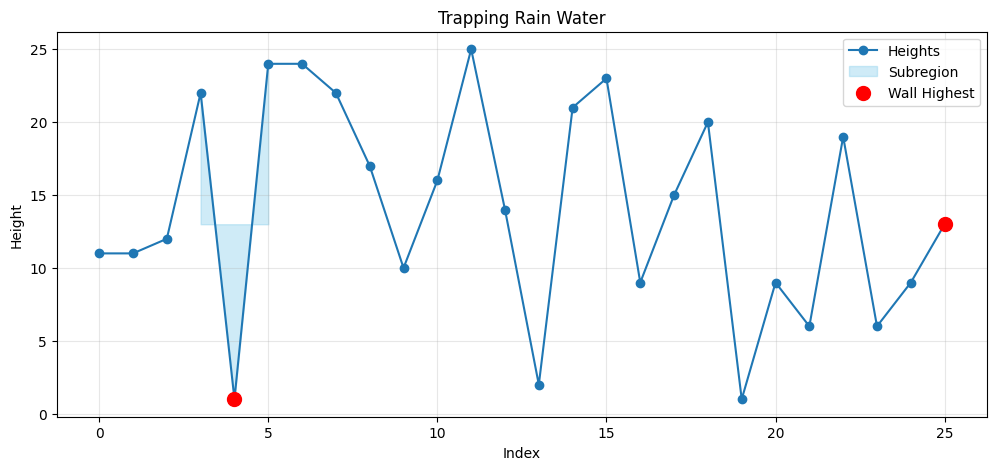

In [824]:
print("Generated data:", rnd_data)

arr_depths_rnd = calculate_deaph_level(rnd_data)
deaph = max(arr_depths_rnd)
count_deaph = list(arr_depths_rnd).count(deaph)

idx_deaph, arr_idx_wall = find_idx_walls_for_deepest_lake(rnd_data)

print("depth of the deepest lake", deaph, "count of the deepest lake", count_deaph, "index of deapest lake", idx_deaph,"arr lakes", arr_idx_wall, sep="\n")
idx1, idx2 = idx_deaph[0], 25
visualize_with_highlights(rnd_data, arr_idx_wall[0][0], arr_idx_wall[0][1] + 1, highest_idxs=[idx1, idx2])

# work

Indexes of the walls for the deepest lake: [array([ 2, 10]), array([10, 17]), array([10, 17])] [array([3, 5]), array([11, 15])]
Indexes of the walls for the deepest lake: 2 10


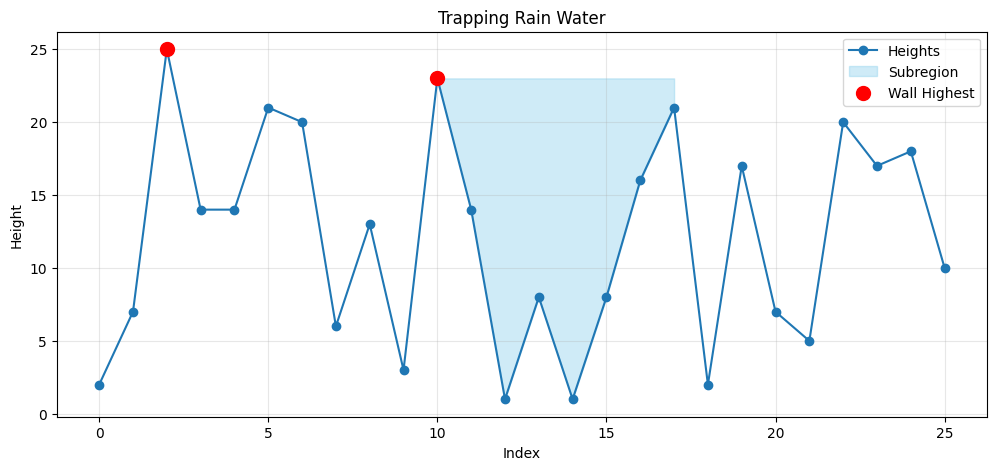

In [ ]:
# that in function find_idx_walls_for_deepest_lake 
pair_idx_wall = np.arange(2)
arr_idx_wall_for_deepest = []

for idx in range(len(indexes_deaph)):
    pair_idx_wall[0] = left_indexes_wall[indexes_deaph[idx]]
    pair_idx_wall[1] = right_indexes_wall[indexes_deaph[idx]]   

    arr_idx_wall_for_deepest.append( pair_idx_wall.copy())
    
    # print("Left wall index:", idx, "index:", left_indexes_wall[indexes_deaph[idx]])
    # print("Right wall index:", idx, "index:", right_indexes_wall[indexes_deaph[idx]])
    # print("Left wall index:", idx, "index:", pair_idx_wall[0])
    # print("Right wall index:", idx, "index:", pair_idx_wall[1])                        
    # print(example_data[left_indexes_wall[indexes_deaph[idx]]], example_data[right_indexes_wall[indexes_deaph[idx]]])

print("Indexes of the walls for the deepest lake:", arr_idx_wall_for_deepest,arr_idx_wall,)

number_idx_wall = 0
idx1, idx2 = arr_idx_wall_for_deepest[number_idx_wall][0], arr_idx_wall_for_deepest[number_idx_wall][1]
print("Indexes of the walls for the deepest lake:", idx1, idx2)
visualize_with_highlights(example_data, start_idx=10, end_idx=18, highest_idxs=[idx1, idx2])


Index | Height | Left Max | Right Max | Water
--------------------------------------------------
    0 |      2 |        2 |        25 |     0
    1 |      7 |        7 |        25 |     0
    2 |     25 |       25 |        25 |     0
    3 |     14 |       25 |        23 |     9
    4 |     14 |       25 |        23 |     9
    5 |     21 |       25 |        23 |     2
    6 |     20 |       25 |        23 |     3
    7 |      6 |       25 |        23 |    17
    8 |     13 |       25 |        23 |    10
    9 |      3 |       25 |        23 |    20
   10 |     23 |       25 |        23 |     0
   11 |     14 |       25 |        21 |     7
   12 |      1 |       25 |        21 |    20
   13 |      8 |       25 |        21 |    13
   14 |      1 |       25 |        21 |    20
   15 |      8 |       25 |        21 |    13
   16 |     16 |       25 |        21 |     5
   17 |     21 |       25 |        21 |     0
   18 |      2 |       25 |        20 |    18
   19 |     17 |       25 |  

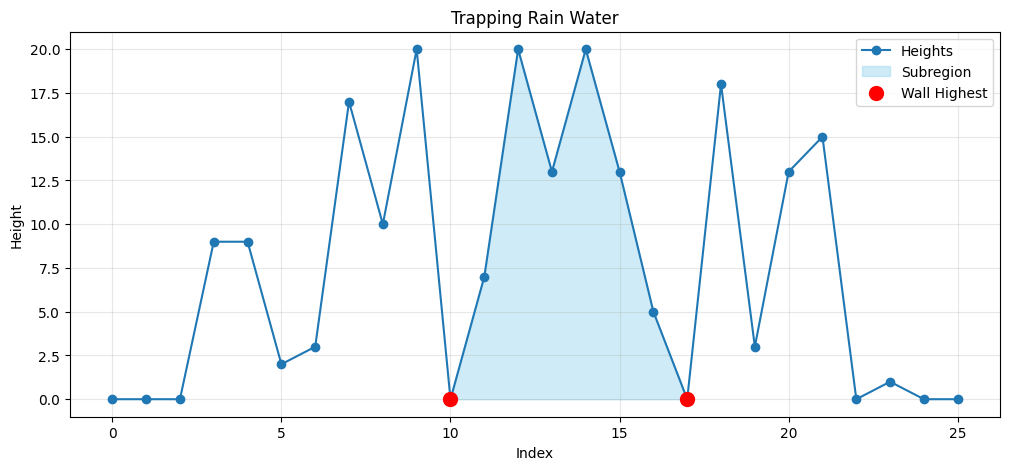

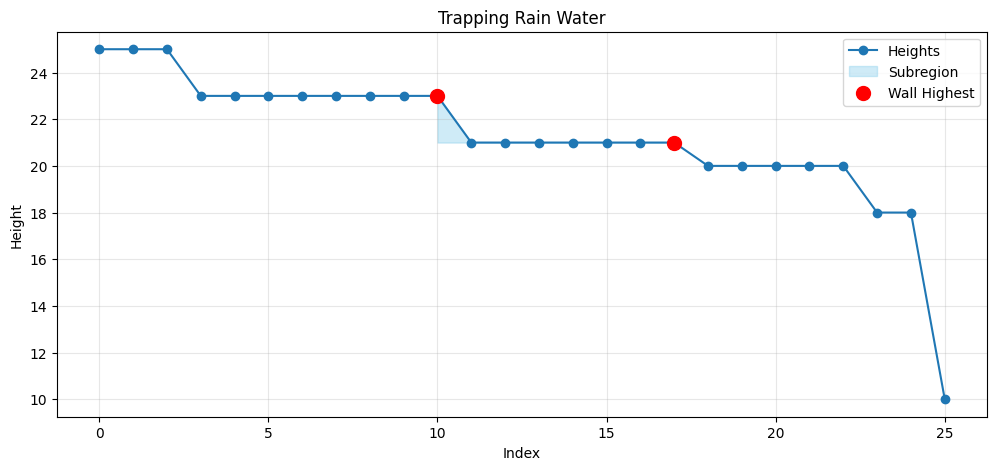

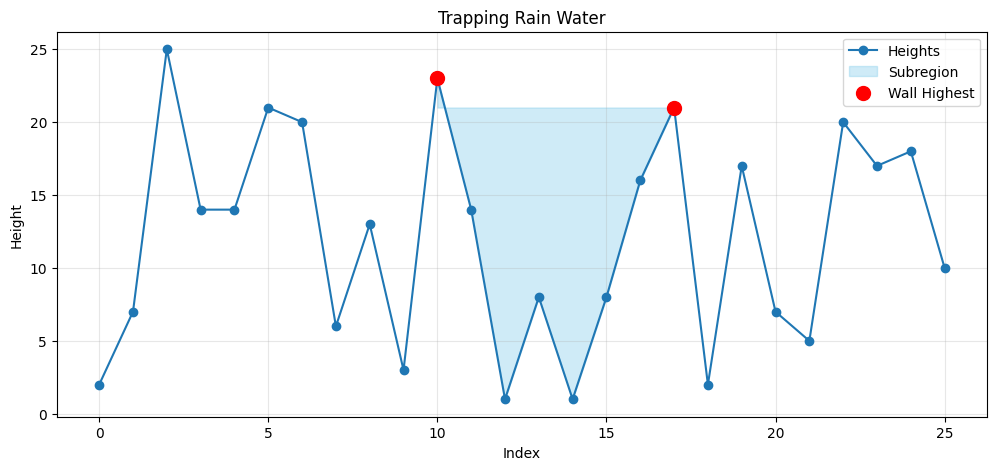

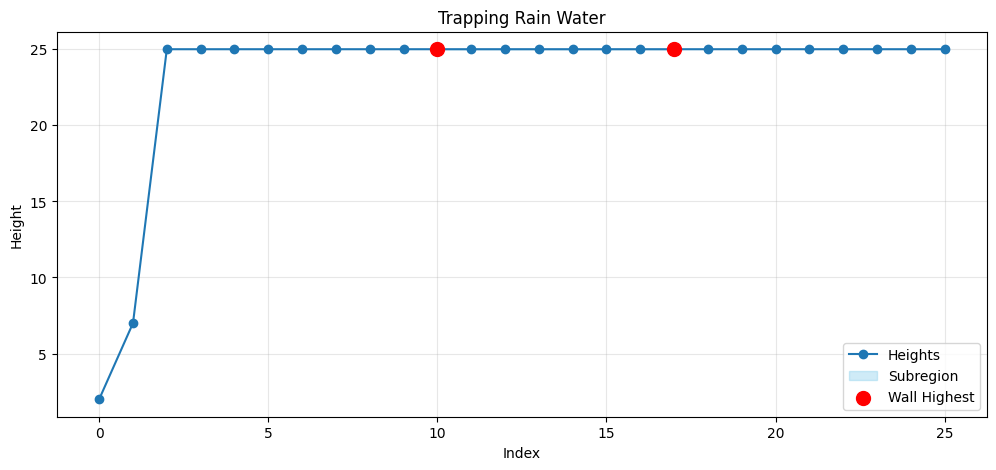

In [829]:
def calculate_deaph_level(arr):
    if len(arr) < 3:
        return 0
    
    left_wall = np.maximum.accumulate(arr)
    right_wall = np.maximum.accumulate(arr[::-1])[::-1] 
    water_level = np.minimum(left_wall, right_wall) - arr

    return water_level

water_level = calculate_deaph_level(example_data)
left_wall = np.maximum.accumulate(example_data)
right_wall = np.maximum.accumulate(example_data[::-1])[::-1] 

# Table format output
print("Index | Height | Left Max | Right Max | Water")
print("-" * 50)
for i in range(len(example_data)):
    print(f"{i:5} | {example_data[i]:6} | {left_wall[i]:8} | {right_wall[i]:9} | {water_level[i]:5}")
visualize_with_highlights(water_level, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(right_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(example_data, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(left_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])

# works rnd

Index | Height | Left Max | Right Max | Water
--------------------------------------------------
    0 |     11 |       11 |        25 |     0
    1 |     11 |       11 |        25 |     0
    2 |     12 |       12 |        25 |     0
    3 |     22 |       22 |        25 |     0
    4 |      1 |       22 |        25 |    21
    5 |     24 |       24 |        25 |     0
    6 |     24 |       24 |        25 |     0
    7 |     22 |       24 |        25 |     2
    8 |     17 |       24 |        25 |     7
    9 |     10 |       24 |        25 |    14
   10 |     16 |       24 |        25 |     8
   11 |     25 |       25 |        25 |     0
   12 |     14 |       25 |        23 |     9
   13 |      2 |       25 |        23 |    21
   14 |     21 |       25 |        23 |     2
   15 |     23 |       25 |        23 |     0
   16 |      9 |       25 |        20 |    11
   17 |     15 |       25 |        20 |     5
   18 |     20 |       25 |        20 |     0
   19 |      1 |       25 |  

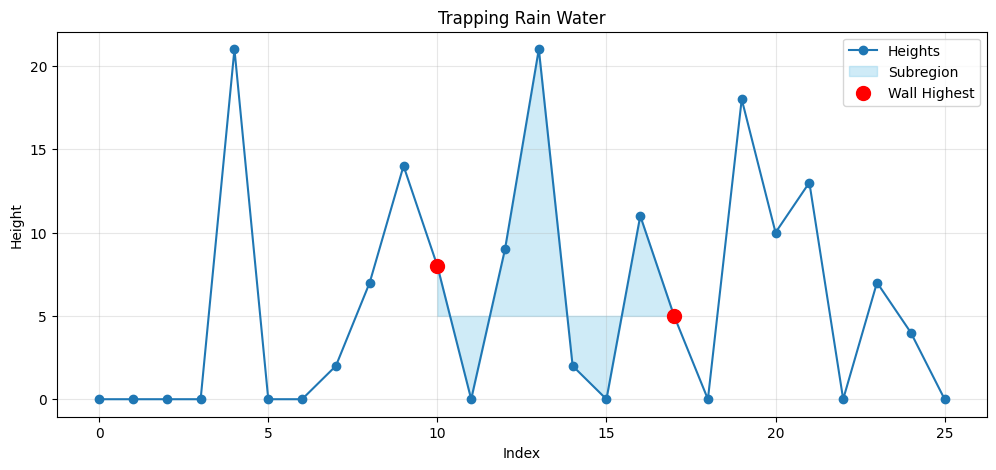

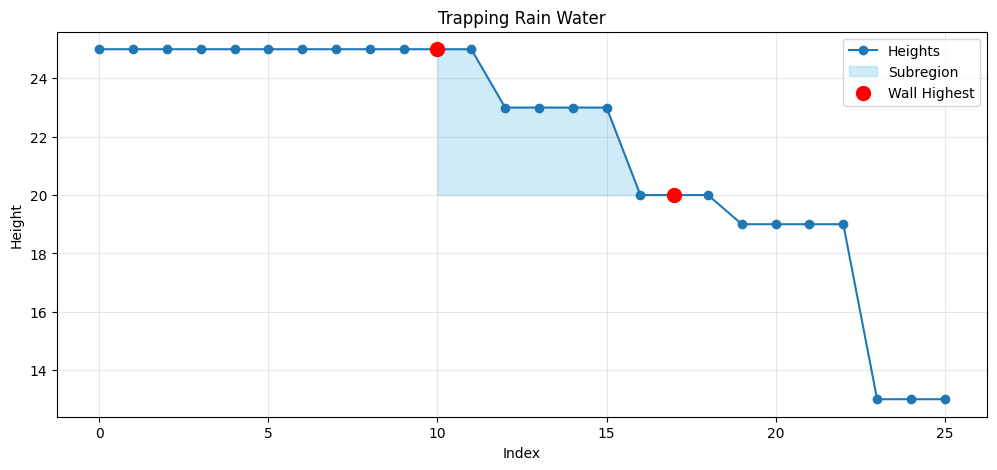

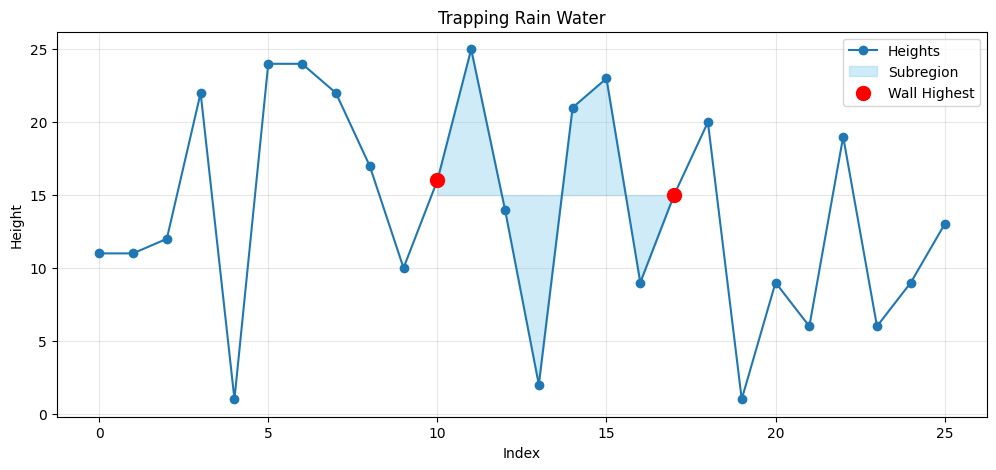

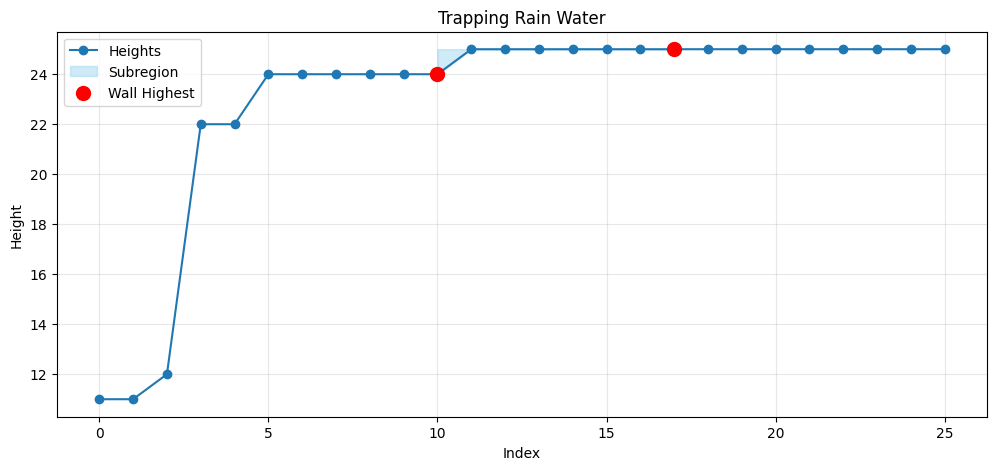

In [830]:

water_level = calculate_deaph_level(rnd_data)
left_wall = np.maximum.accumulate(rnd_data)
right_wall = np.maximum.accumulate(rnd_data[::-1])[::-1] 

# Table format output
print("Index | Height | Left Max | Right Max | Water")
print("-" * 50)
for i in range(len(rnd_data)):
    print(f"{i:5} | {rnd_data[i]:6} | {left_wall[i]:8} | {right_wall[i]:9} | {water_level[i]:5}")
visualize_with_highlights(water_level, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(right_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(rnd_data, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(left_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])